In [1]:
import numpy as np

def markov_chain(P, pi0, N):
    P = np.array(P)
    pi = np.array(pi0)

    results = [pi]

    for k in range(N):
        pi = pi @ P
        results.append(pi)

    return np.array(results)

def check_convergence(results, tol=1e-6):
    diffs = np.linalg.norm(results[1:] - results[:-1], axis=1)
    return np.all(diffs[-10:] < tol)

# Example
P1 = [  [0.5, 0.5], 
        [0.4, 0.6]
        ]

pi0 = [0.8, 0.2]

res = markov_chain(P1, pi0, 50)

print(res)
print("Converges:", check_convergence(res))

[[0.8        0.2       ]
 [0.48       0.52      ]
 [0.448      0.552     ]
 [0.4448     0.5552    ]
 [0.44448    0.55552   ]
 [0.444448   0.555552  ]
 [0.4444448  0.5555552 ]
 [0.44444448 0.55555552]
 [0.44444445 0.55555555]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]
 [0.44444444 0.55555556]


In [2]:
import numpy as np

def markov_chain(P, pi0, N):
    P = np.array(P)
    pi = np.array(pi0)

    results = [pi]

    for _ in range(N):
        pi = pi @ P
        results.append(pi)

    return np.array(results)

def check_convergence(results, tol=1e-6):
    diffs = np.linalg.norm(results[1:] - results[:-1], axis=1)
    return np.all(diffs[-10:] < tol)

def is_irreducible(P):
    P = np.array(P)
    n = P.shape[0]
    reach = np.copy(P)

    for _ in range(n):
        reach = reach + reach @ P

    return np.all(reach > 0)

def period(P, state=0, max_steps=100):
    Pk = np.eye(len(P))
    times = []

    for k in range(1, max_steps):
        Pk = Pk @ P
        if Pk[state, state] > 0:
            times.append(k)

    from math import gcd
    d = times[0]
    for t in times[1:]:
        d = gcd(d, t)
    if d == 1:
        return "aperiodic"
    else:
        return "periodic with period " + str(d)

# Cases
P1 = [[0.5,0.5],[0.4,0.6]]
pi0 = [0.8,0.2]
num_steps = 1000

P2 = [[0,1],[1,0]]
p20 = [1,0]

P3 = [[0.6,0.3,0.1],[0.2,0.5,0.3],[0.1,0.4,0.5]]
p30 = [0.2,0.5,0.3]

print("Case 1:")
res1 = markov_chain(P1, pi0, num_steps)
print("Converges:", check_convergence(res1))
print("Irreducible:", is_irreducible(P1))
print("Period:", period(P1))

print("\nCase 2:")
res2 = markov_chain(P2, p20, num_steps)
print("Converges:", check_convergence(res2))
print("Irreducible:", is_irreducible(P2))
print("Period:", period(P2))

print("\nCase 3:")
res3 = markov_chain(P3, p30, num_steps)
print("Converges:", check_convergence(res3))
print("Irreducible:", is_irreducible(P3))
print("Period:", period(P3))

Case 1:
Converges: True
Irreducible: True
Period: aperiodic

Case 2:
Converges: False
Irreducible: True
Period: periodic with period 2

Case 3:
Converges: True
Irreducible: True
Period: aperiodic


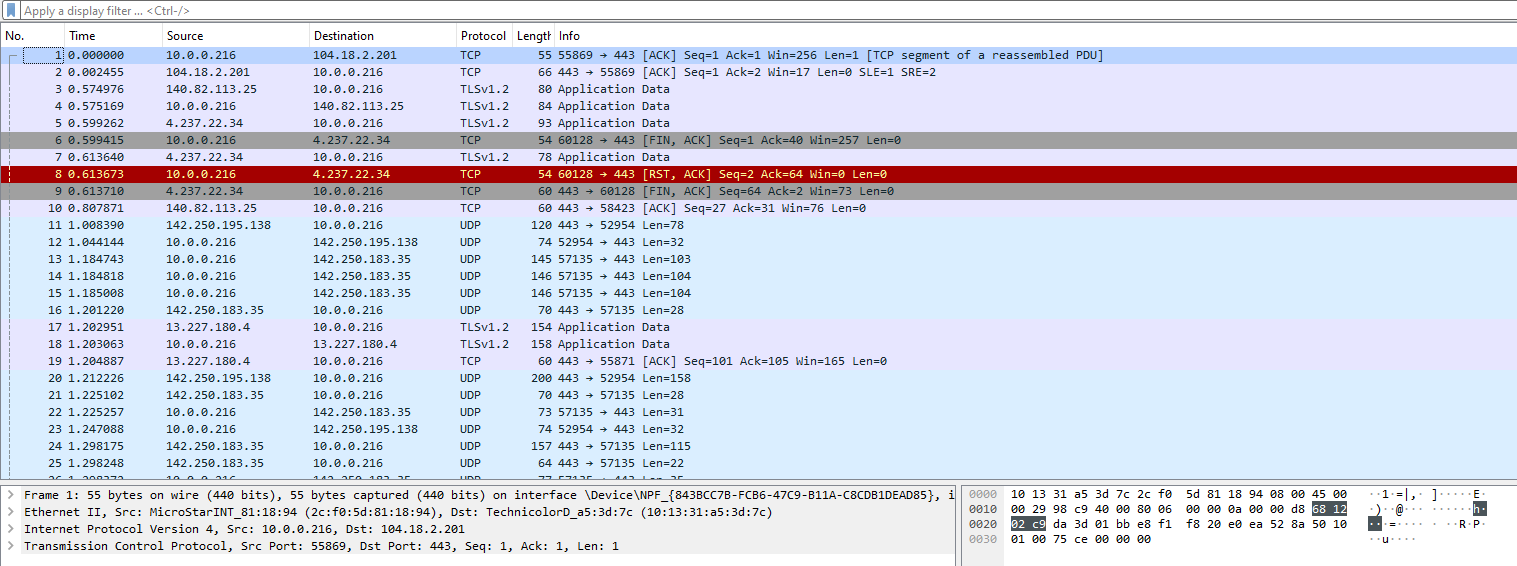
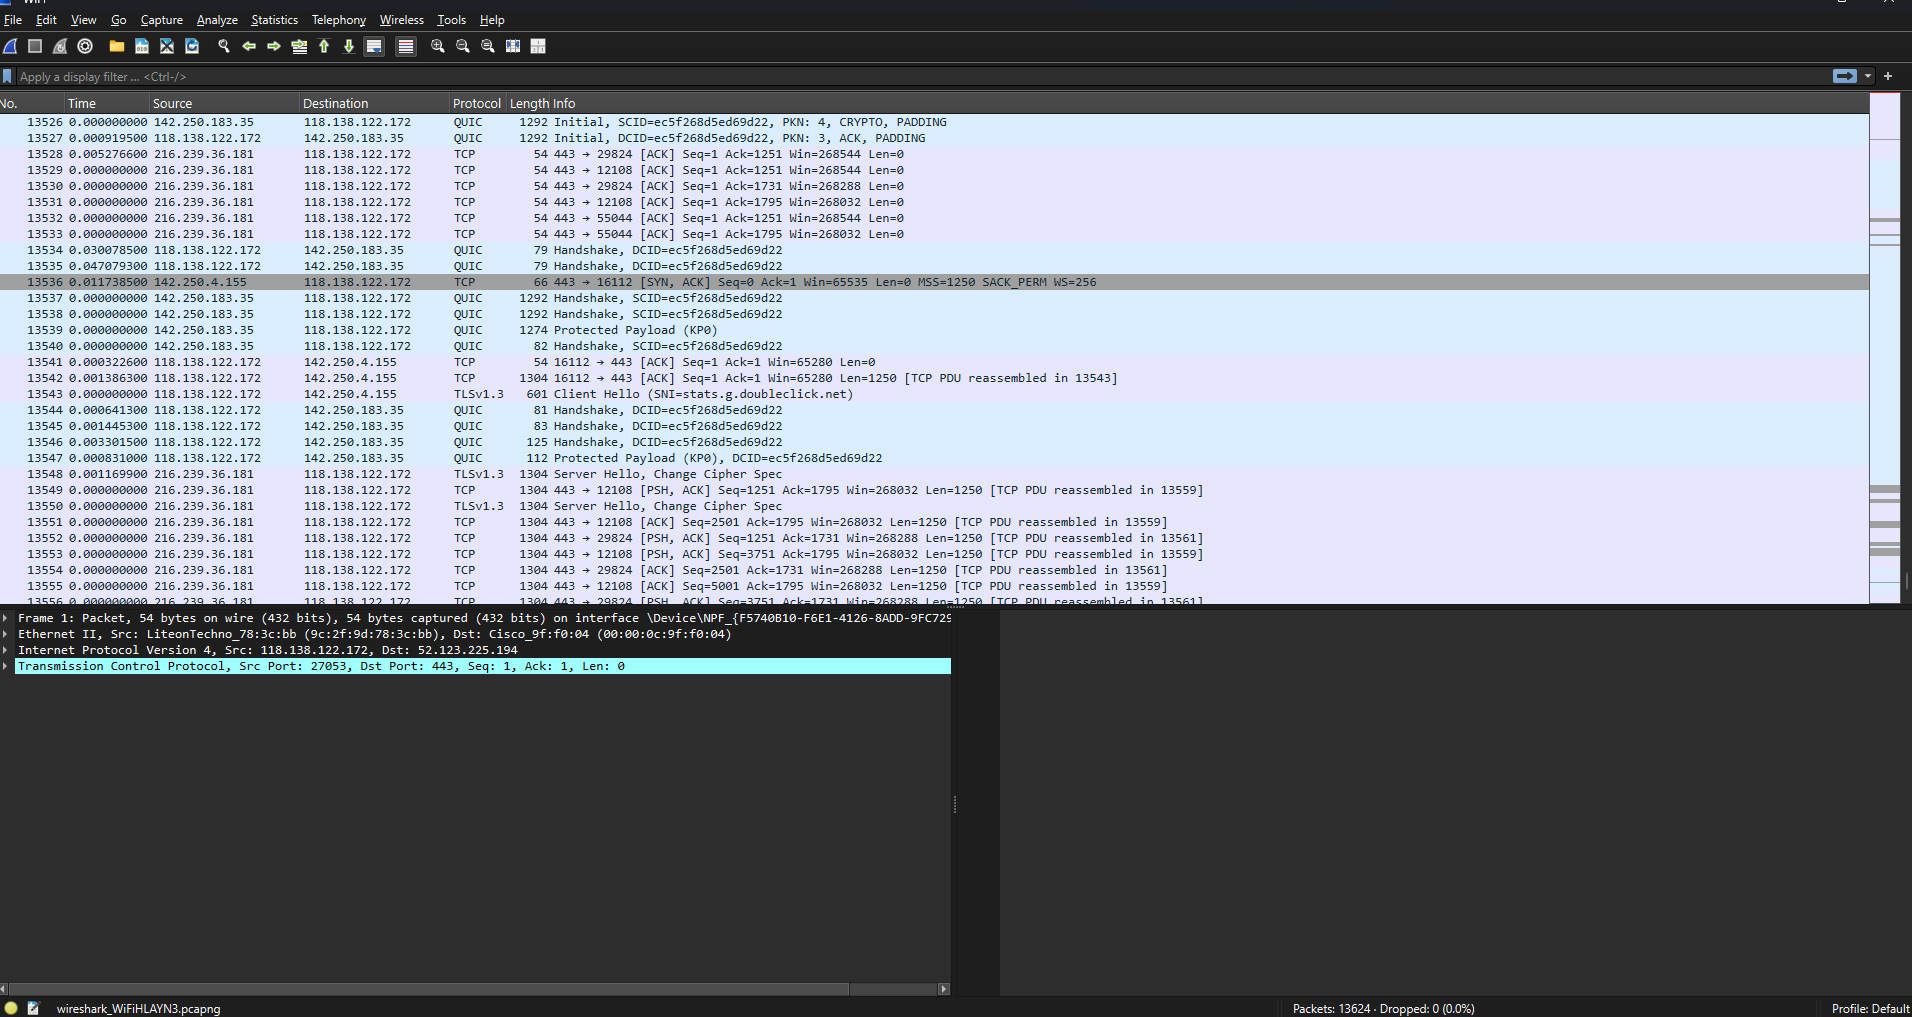

Mean: 0.015832273476112022
Variance: 0.0010185104077143417


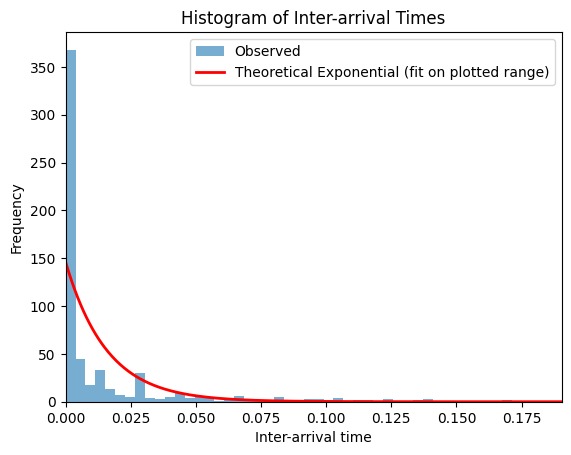

Poisson lambda (mean arrivals per interval): 6.7500


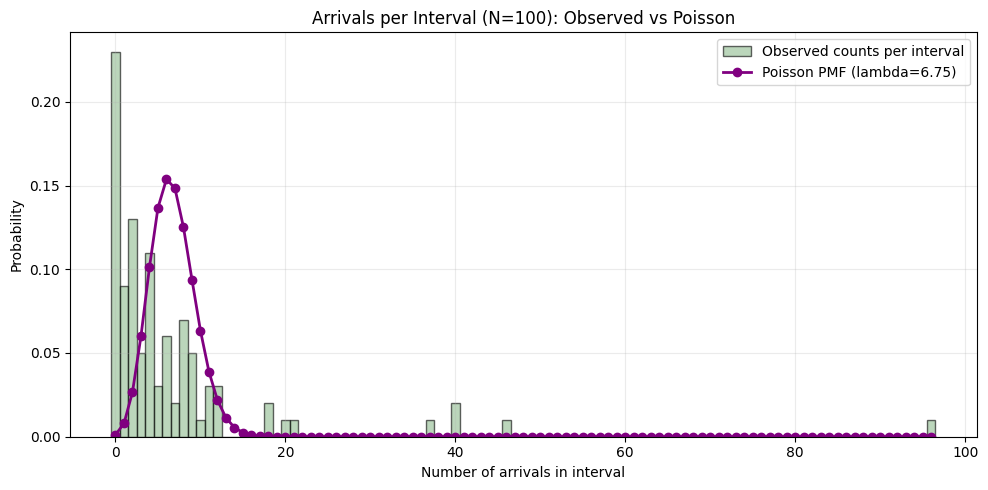

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# Load CSV
df = pd.read_csv("wireshark3.csv")

# sorting is important
df = df.sort_values(by="Time")

# Compute inter-arrival times
df["interarrival"] = df["Time"].diff()

# Remove NaN
interarrivals = df["interarrival"].dropna()

# Choose a zoom range
# Example: show only values up to the 95th percentile
xmax = np.percentile(interarrivals, 90)

mean = np.mean(interarrivals)
variance = np.var(interarrivals)

# Use only plotted percentile range for exponential fit
interarrivals_plot = interarrivals[interarrivals <= xmax]
mean_plot = np.mean(interarrivals_plot)
variance_plot = np.var(interarrivals_plot)

# Mean and variance
print("Mean:", mean_plot)
print("Variance:", variance_plot)

# Plot zoomed histogram
counts, bins, patches = plt.hist(interarrivals, bins=50, range=(0, xmax), alpha=0.6, label="Observed")
plt.xlim(0, xmax)
plt.xlabel("Inter-arrival time")
plt.ylabel("Frequency")
plt.title("Histogram of Inter-arrival Times")



# Overlay theoretical exponential PDF (scaled to match histogram)
lambda_hat = 1 / mean_plot
x = np.linspace(0, xmax, 500)
pdf = lambda_hat * np.exp(-lambda_hat * x)
area = len(interarrivals_plot) * (xmax / 50)
plt.plot(x, pdf * area, 'r-', lw=2, label='Theoretical Exponential (fit on plotted range)')

plt.legend()
plt.show()

Mean_interarrival_time = np.mean(interarrivals)




# --- Poisson arrivals per interval analysis ---
# Use absolute times for arrivals (excluding the first, since diff drops one)
arrival_times = df["Time"].iloc[1:].to_numpy()

# Number of intervals (can adjust as needed)
N = 100
interval_edges = np.linspace(arrival_times[0], arrival_times[-1], N + 1)
counts_per_interval, _ = np.histogram(arrival_times, bins=interval_edges)

# Poisson parameter: mean arrivals per interval
poisson_lambda = counts_per_interval.mean()
print(f"Poisson lambda (mean arrivals per interval): {poisson_lambda:.4f}")

# Plot histogram of observed counts per interval
fig, ax = plt.subplots(figsize=(10, 5))
k_min = int(counts_per_interval.min())
k_max = int(counts_per_interval.max())
count_bins = np.arange(k_min - 0.5, k_max + 1.5, 1)
ax.hist(counts_per_interval, bins=count_bins, density=True, alpha=0.6, color="darkseagreen", edgecolor="black", label="Observed counts per interval")

# Overlay Poisson PMF
k_vals = np.arange(k_min, k_max + 1)
if poisson_lambda == 0:
    poisson_pmf = np.where(k_vals == 0, 1.0, 0.0)
else:
    log_pmf = -poisson_lambda + k_vals * np.log(poisson_lambda) - np.array([math.lgamma(k + 1) for k in k_vals])
    poisson_pmf = np.exp(log_pmf)
ax.plot(k_vals, poisson_pmf, "o-", color="purple", linewidth=2, label=f"Poisson PMF (lambda={poisson_lambda:.2f})")

ax.set_title(f"Arrivals per Interval (N={N}): Observed vs Poisson")
ax.set_xlabel("Number of arrivals in interval")
ax.set_ylabel("Probability")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()